____
# Colocalization dataset
- put all variables for reconstruction in the same file


In [1]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from cstes import swot_dir, drifters_dir, get_proj, lonlat2xy, zarr_dir, surface_drifters, depth_drifters, depth_100, depth_50, images_dir, U2, err_acc
from swot import browse_swot_250, add_mask_inside_swot, build_swath_polygon, browse_swot_2km
from diagnosis import dataset_coloc_combs, DRIFTER, ALTI, WD, prepared_drifters, prepared_wd, prepared_alti, compute_mean_square, compute_mean_square_groupby

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo
crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pyproj
from pyproj import Geod

from rasterio.transform import Affine

import pynsitu as pyn

from diagnosis import synthetic_figure
from cstes import U2, c0, U

c0 ={'acc':'#941717', 'cor':'#388E3C','ggd':'#42A5F5', 'wd':'#FFA000'}

_______
# Data

In [2]:
DRIFTER.keys(), ALTI.keys(), WD.keys()
# wd_depth = '0' or '15'
# ggd_var = 'etaf', 'etac', 'adtf', 'adtc', 'fromduacsv'

(dict_keys(['nofilter']),
 dict_keys(['swot250naive', 'swot2kmnaive', 'L4noswotregional', 'L4noswotglobal', 'L4withswot']),
 dict_keys(['era5']))

In [3]:
comb_list = [dict(drifter_key='nofilter', spectral_key = '', alti_key = 'swot2kmnaive', wd_key = 'era5', ggd_var='etaf', wd_depth='0'),
            dict(drifter_key='nofilter', spectral_key = 'LF', alti_key = 'swot2kmnaive', wd_key = 'era5', ggd_var='etaf', wd_depth='0'),
             dict(drifter_key='nofilter', spectral_key = 'inertial', alti_key = 'swot2kmnaive', wd_key = 'era5', ggd_var='etaf', wd_depth='0'), 
            dict(drifter_key='nofilter', spectral_key = 'diurnal', alti_key = 'swot2kmnaive', wd_key = 'era5', ggd_var='etaf', wd_depth='0'),
            dict(drifter_key='nofilter', spectral_key = 'semidiurnal', alti_key = 'swot2kmnaive', wd_key = 'era5', ggd_var='etaf', wd_depth='0'),
            dict(drifter_key='nofilter', spectral_key = 'HF', alti_key = 'swot2kmnaive', wd_key = 'era5', ggd_var='etaf', wd_depth='0'),]

DS = dataset_coloc_combs(comb_list, nearest =False)
DS = DS.where(DS.time_to_swot/pd.Timedelta('1h')<12).dropna('row_number')
DSS = DS.where(DS.depth==0, drop=True)
#DSD = DS.where(DS.depth==15, drop=True).isel(id_comb=[1])
DSS

/Users/mdemol/code/med_analysis/diagnosis.py:96: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dfs['ggde_fromduacsv'] = dfs.f * dfs.duacs_speed_meridional_abs
/Users/mdemol/code/med_analysis/diagnosis.py:97: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dfs['ggdn_fromduacsv'] = -dfs.f *dfs.duacs_speed_zonal_abs


nofilter___swot2kmnaive_etaf__rio_0era5


/Users/mdemol/code/med_analysis/diagnosis.py:96: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dfs['ggde_fromduacsv'] = dfs.f * dfs.duacs_speed_meridional_abs
/Users/mdemol/code/med_analysis/diagnosis.py:97: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dfs['ggdn_fromduacsv'] = -dfs.f *dfs.duacs_speed_zonal_abs


nofilter_LF__swot2kmnaive_etaf__rio_0era5


/Users/mdemol/code/med_analysis/diagnosis.py:96: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dfs['ggde_fromduacsv'] = dfs.f * dfs.duacs_speed_meridional_abs
/Users/mdemol/code/med_analysis/diagnosis.py:97: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dfs['ggdn_fromduacsv'] = -dfs.f *dfs.duacs_speed_zonal_abs


...

/Users/mdemol/code/med_analysis/diagnosis.py:96: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dfs['ggde_fromduacsv'] = dfs.f * dfs.duacs_speed_meridional_abs
/Users/mdemol/code/med_analysis/diagnosis.py:97: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dfs['ggdn_fromduacsv'] = -dfs.f *dfs.duacs_speed_zonal_abs


nofilter_semidiurnal__swot2kmnaive_etaf__rio_0era5


/Users/mdemol/code/med_analysis/diagnosis.py:96: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dfs['ggde_fromduacsv'] = dfs.f * dfs.duacs_speed_meridional_abs
/Users/mdemol/code/med_analysis/diagnosis.py:97: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dfs['ggdn_fromduacsv'] = -dfs.f *dfs.duacs_speed_zonal_abs


nofilter_HF__swot2kmnaive_etaf__rio_0era5
Identified SWOT and drifter outliers have been removed


<xarray.Dataset> Size: 291MB
Dimensions:        (id_comb: 6, row_number: 150948)
Coordinates:
    datetime       (id_comb, row_number) datetime64[ns] 7MB 2023-04-01T11:50:...
    longitude      (id_comb, row_number) float64 7MB 5.538 5.539 ... 2.014 2.012
    latitude       (id_comb, row_number) float64 7MB 42.31 42.31 ... 41.06 41.06
    pass_number    (id_comb, row_number) int64 7MB 3 3 3 3 3 ... 16 16 16 16 16
    time_to_swot   (id_comb, row_number) timedelta64[ns] 7MB 11:52:32.696536 ...
    cycle_number   (id_comb, row_number) int64 7MB 478 478 478 ... 577 577 577
    drifter_id     (id_comb, row_number) object 7MB '0-4351296' ... '295'
    drifter_type   (id_comb, row_number) object 7MB 'CARTHE' ... 'HEREON'
    depth          (id_comb, row_number) int64 7MB 0 0 0 0 0 0 0 ... 0 0 0 0 0 0
    phi            (id_comb, row_number) float64 7MB 0.2477 0.2478 ... 2.91 2.91
  * row_number     (row_number) int64 1MB 144 145 146 ... 376432 376433 376434
  * id_comb        (id_comb) <U50 1kB 'nofilter___swot2kmnaive_etaf__rio_0era...
Data variables: (12/30)
    sume           (id_comb, row_number) float64 7MB -2.366e-05 ... -2.197e-05
    acce           (id_comb, row_number) float64 7MB -7.905e-06 ... -4.535e-06
    exce_acc       (id_comb, row_number) float64 7MB -1.575e-05 ... -1.743e-05
    core           (id_comb, row_number) float64 7MB 1.226e-05 ... 2.798e-06
    exce_cor       (id_comb, row_number) float64 7MB -3.592e-05 ... -2.477e-05
    ggde           (id_comb, row_number) float64 7MB 9.622e-07 ... -1.727e-05
    ...             ...
    prodn_acc_cor  (id_comb, row_number) float64 7MB 3.142e-11 ... -1.596e-12
    prodn_acc_ggd  (id_comb, row_number) float64 7MB -5.887e-12 ... 9.805e-12
    prodn_acc_wd   (id_comb, row_number) float64 7MB -2.746e-11 ... 5.593e-12
    prodn_cor_ggd  (id_comb, row_number) float64 7MB -4.024e-11 ... -1.763e-11
    prodn_cor_wd   (id_comb, row_number) float64 7MB -1.877e-10 ... -1.006e-11
    prodn_ggd_wd   (id_comb, row_number) float64 7MB 3.516e-11 ... 6.179e-11

/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_94893/3274660881.py:7: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df.loc['sum_spectral'][v.replace('*', d)] = df.loc['nofilter___swot2kmnaive_etaf__rio_0era5'][v.replace('*', d)]


8.013159580223276
8.423229368174333
8.09092305806513
8.29907332247894
4.307965677940436
4.463552881442655
4.287038802401437
4.401481882773236
4.36230294208651
4.597174846586418
4.347403586281854
4.387227212066523
2.384706131103638
2.5550367496582633
2.336523785908785
2.3771552181006212
2.1220000865247575
2.2178242819462803
2.118239956607152
2.109769470624766
2.846490433285854
2.9397413456779673
2.7337232316822995
2.7237232316823
7.78912563747874
8.340974405015949
7.632814635443695
7.64487935610704


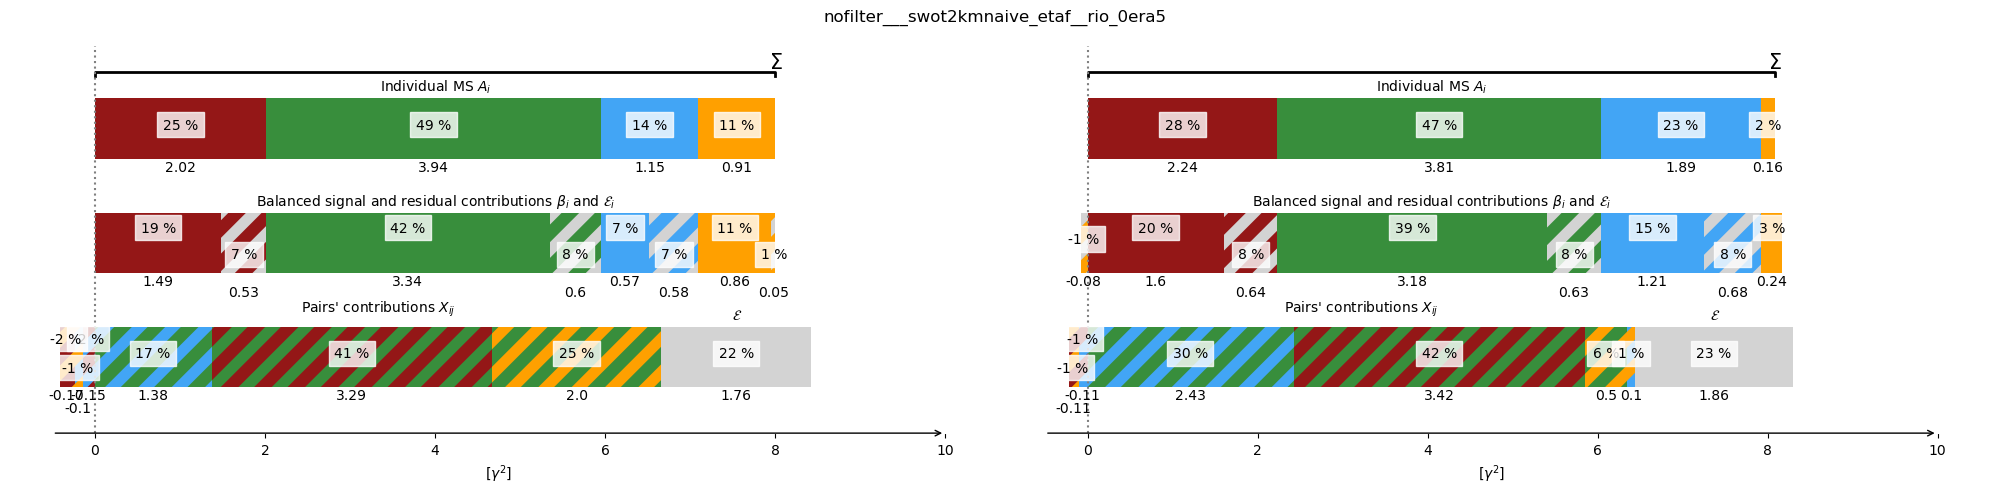

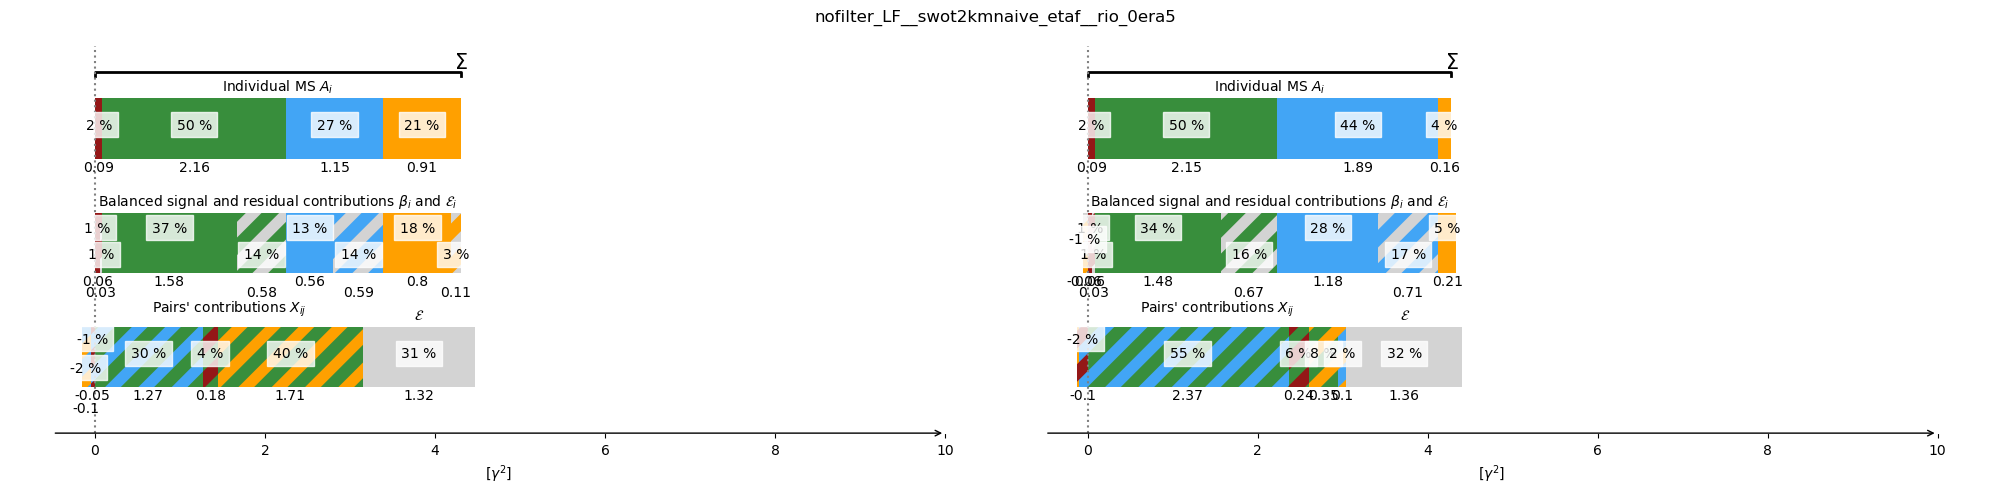

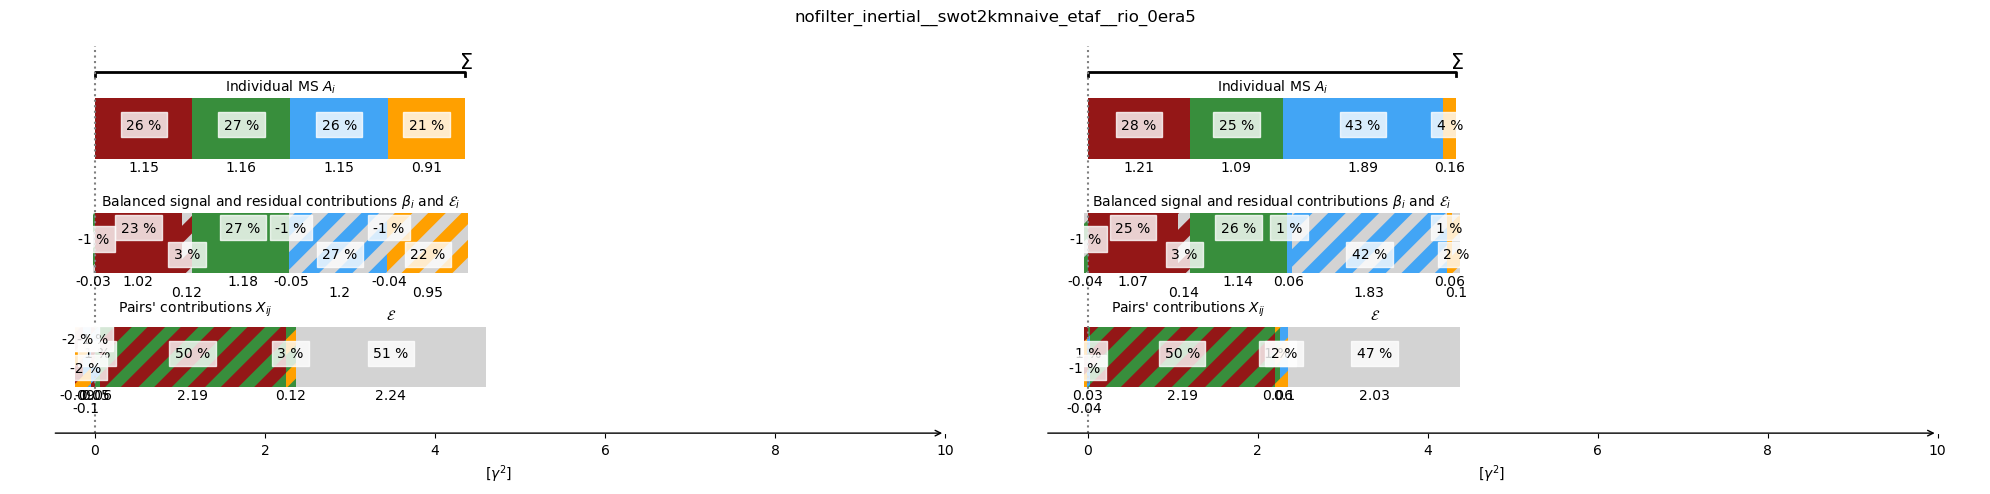

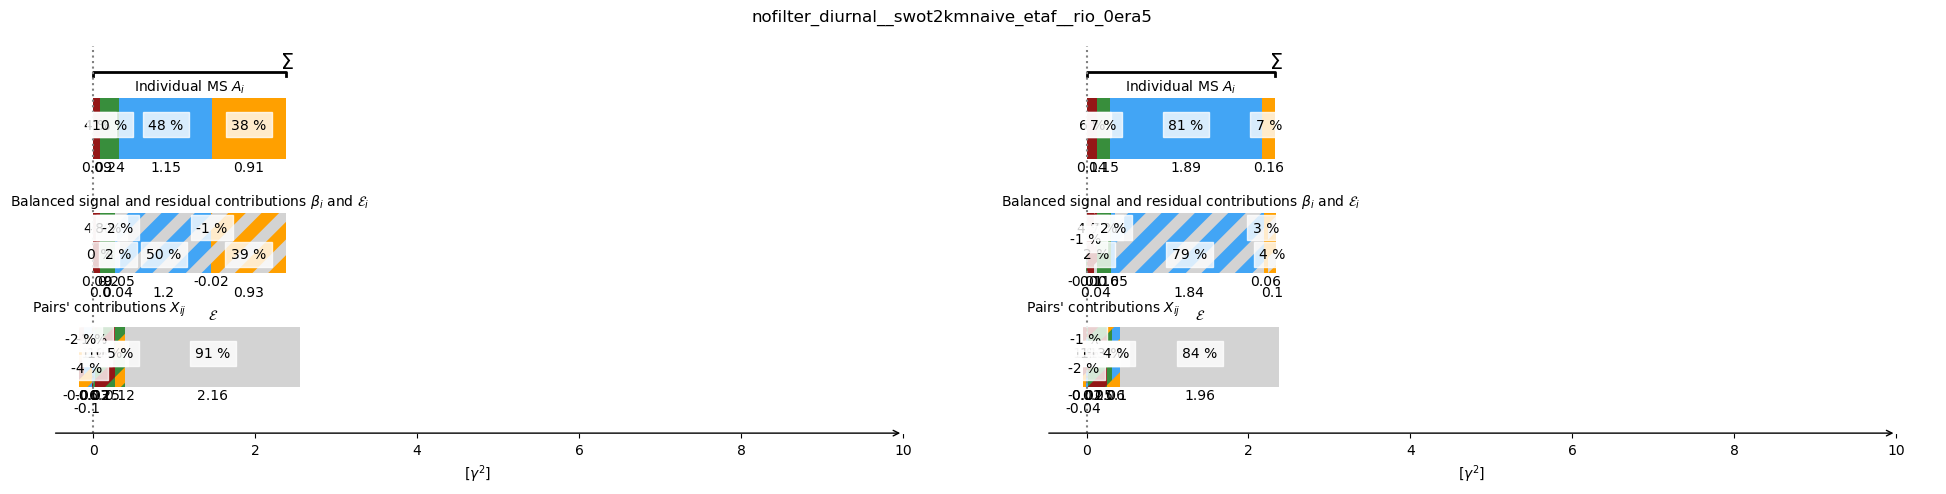

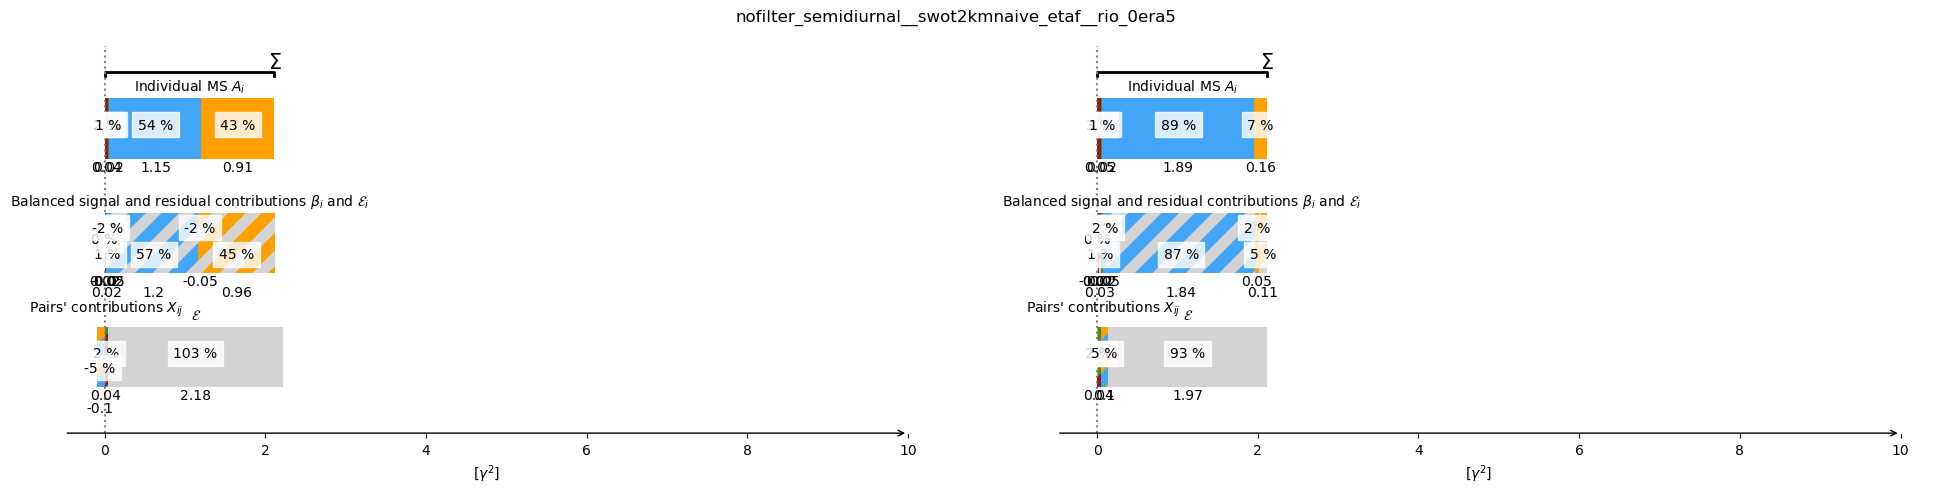

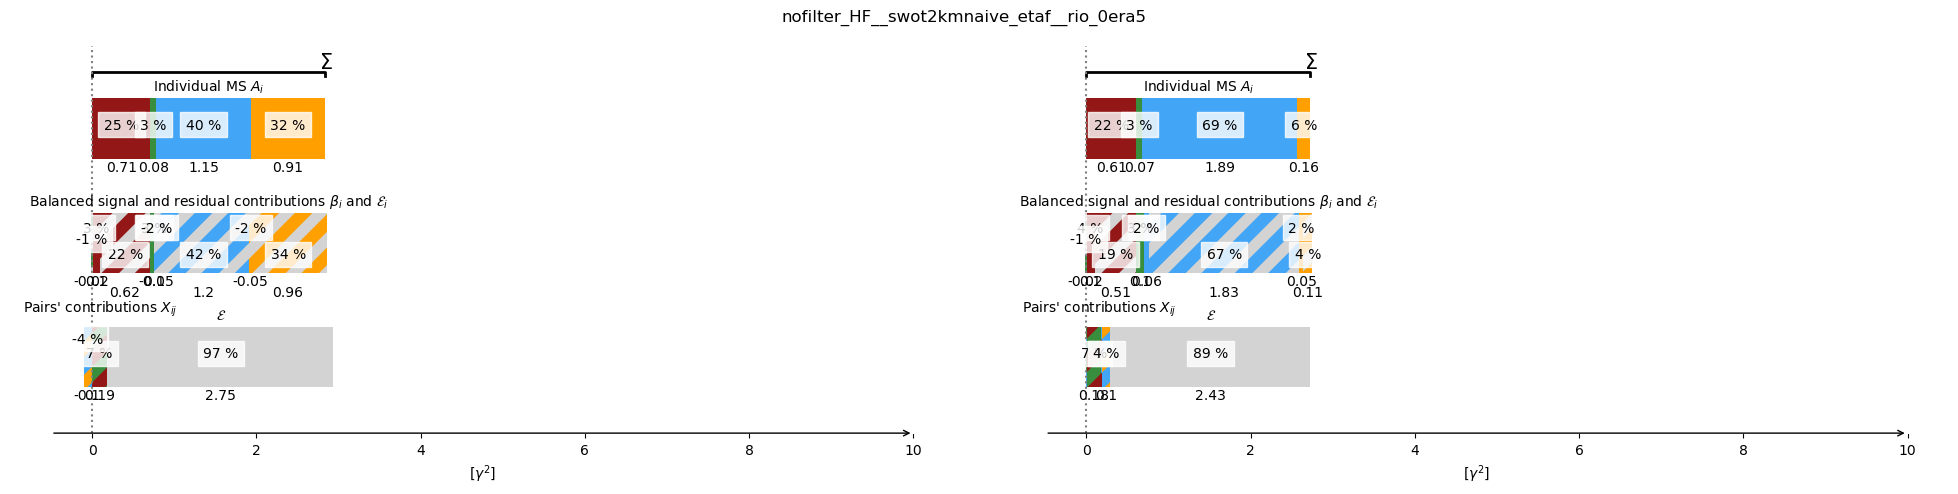

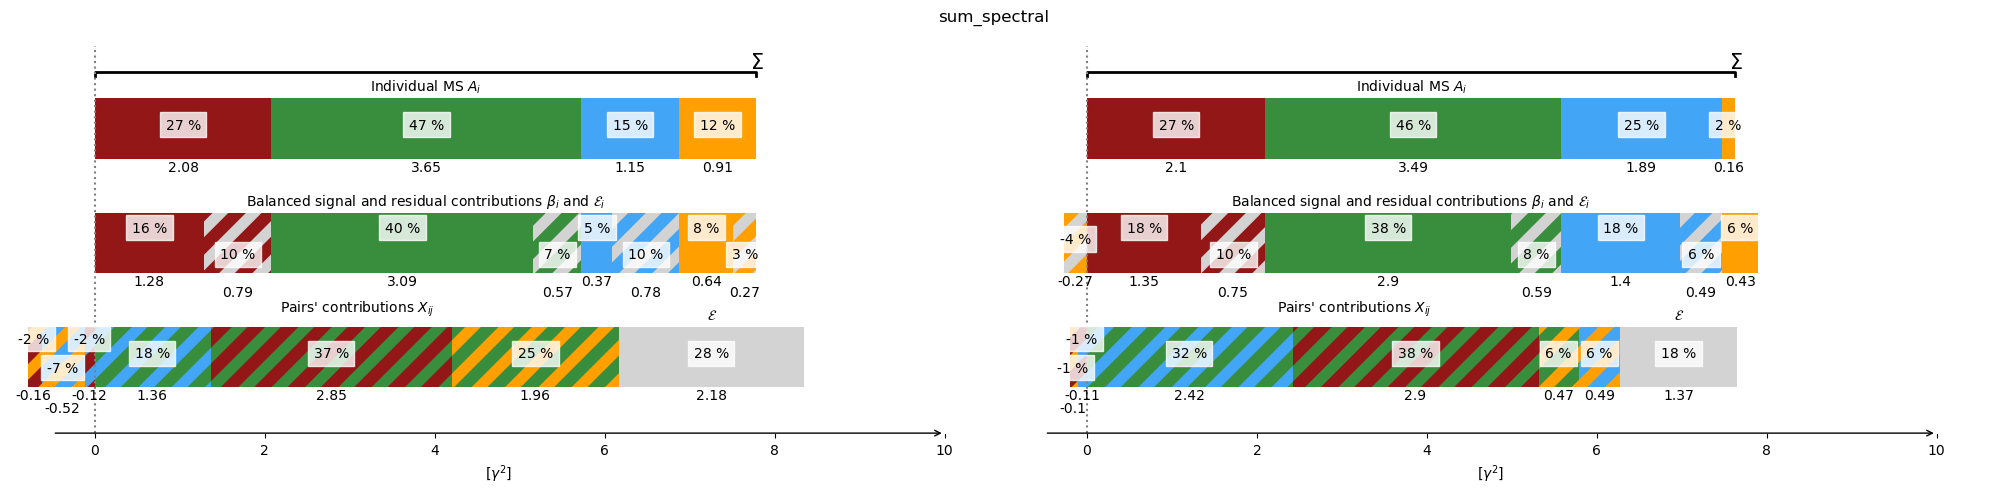

In [32]:
ds = compute_mean_square(DSS)/U2
df = ds.to_dataframe()
df.loc['sum_spectral'] = df.iloc[1:6].sum()

for d in ['', 'e', 'n']:
    for v in ['GGD*', 'WD*'] :
        df.loc['sum_spectral'][v.replace('*', d)] = df.loc['nofilter___swot2kmnaive_etaf__rio_0era5'][v.replace('*', d)]
    df.loc['sum_spectral', 'E*_ggd'.replace('*', d)]= df.loc['sum_spectral','GGD*'.replace('*', d)] - df.loc['sum_spectral','B*_ggd'.replace('*', d)]
    df.loc['sum_spectral','E*_wd'.replace('*', d)]= df.loc['sum_spectral','WD*'.replace('*', d)] - df.loc['sum_spectral','B*_wd'.replace('*', d)]
    df.loc['sum_spectral','sigma*'.replace('*', d)]= df.loc['sum_spectral'][[v.replace('*', d) for v in ['ACC*', 'COR*', 'GGD*', 'WD*']]].sum()
    df.loc['sum_spectral','S*'.replace('*', d)] = df.loc['sum_spectral', 'sigma*'.replace('*', d)] - df.loc['sum_spectral'][[v.replace('*', d) for v in [v for v in df.columns if 'X*_'.replace('*',d) in v]]].sum()

for c in df.index :
    plt.rcParams["axes.edgecolor"] = "w"
    fig, axs = plt.subplots(nrows=1,ncols=2,figsize=(20,5), frameon=False)
    synthetic_figure(df.loc[c], axs[0], dir='e', xlim=[-1, 10])
    synthetic_figure(df.loc[c], axs[1], dir='n', xlim=[-1, 10])
    fig.suptitle(c)
    fig.tight_layout()
    fig.savefig(os.path.join(images_dir, 'closure_figs', '15m_' + c + '.png'))


In [33]:
df

,ACCn,CORn,GGDn,WDn,Sn,ACCe,CORe,GGDe,WDe,Se,...,ser__E_ggd,ser__E_wd,ser__X_acc_cor,ser__X_acc_ggd,ser__X_acc_wd,ser__X_cor_ggd,ser__X_cor_wd,ser__X_ggd_wd,ser__D_cyclo,ser__D_anticyclo
id_comb,,,,,,,,,,,,,,,,,,,,,
nofilter___swot2kmnaive_etaf__rio_0era5,2.237702,3.805692,1.890029,0.1575,1.859232,2.015577,3.938997,1.149717,0.908868,1.762385,...,0.016674,0.013888,0.057779,0.025473,0.014887,0.041314,0.036017,0.011555,0.035984,0.075280
nofilter_LF__swot2kmnaive_etaf__rio_0era5,0.088463,2.151047,1.890029,0.1575,1.355860,0.088520,2.160860,1.149717,0.908868,1.315390,...,0.015521,0.013914,0.008925,0.006203,0.003727,0.034227,0.029836,0.011555,0.032389,0.038340
nofilter_inertial__swot2kmnaive_etaf__rio_0era5,1.208181,1.091693,1.890029,0.1575,2.026741,1.146442,1.157276,1.149717,0.908868,2.237579,...,0.022315,0.024105,0.031058,0.017482,0.010195,0.017263,0.010452,0.011555,0.006411,0.035951
nofilter_diurnal__swot2kmnaive_etaf__rio_0era5,0.137005,0.151990,1.890029,0.1575,1.962181,0.088763,0.237358,1.149717,0.908868,2.164899,...,0.022352,0.024274,0.002925,0.005445,0.003163,0.007294,0.004705,0.011555,0.004019,0.007920
nofilter_semidiurnal__swot2kmnaive_etaf__rio_0era5,0.053411,0.017301,1.890029,0.1575,1.971237,0.040773,0.022642,1.149717,0.908868,2.177893,...,0.022319,0.024511,0.000654,0.003786,0.002161,0.002464,0.001334,0.011555,0.002565,0.002550
nofilter_HF__swot2kmnaive_etaf__rio_0era5,0.611402,0.074793,1.890029,0.1575,2.429301,0.712419,0.075486,1.149717,0.908868,2.750726,...,0.023301,0.024649,0.004823,0.015537,0.006626,0.005064,0.003010,0.011555,0.014406,0.006955
sum_spectral,2.098462,3.486824,1.890029,0.1575,1.372238,2.076918,3.653623,1.149717,0.908868,2.180269,...,0.105808,0.111453,0.048384,0.048454,0.025873,0.066312,0.049337,0.057774,0.059790,0.091716


In [34]:
df.sigma

id_comb
nofilter___swot2kmnaive_etaf__rio_0era5               16.104083
nofilter_LF__swot2kmnaive_etaf__rio_0era5              8.595004
nofilter_inertial__swot2kmnaive_etaf__rio_0era5        8.709707
nofilter_diurnal__swot2kmnaive_etaf__rio_0era5         4.721230
nofilter_semidiurnal__swot2kmnaive_etaf__rio_0era5     4.240240
nofilter_HF__swot2kmnaive_etaf__rio_0era5              5.580214
sum_spectral                                          15.421940
Name: sigma, dtype: float64